## Q1. Write a query to list the top 10 genres with the highest number of tracks. (Show in bar plot)

In [6]:
import pandas as pd
import sqlite3 as sql
import matplotlib.pyplot as plt

In [4]:
conn = sql.connect("chinook.db")

def sql_query(q):
    return pd.read_sql_query(q,conn)

In [5]:
sql_query("select * from sqlite_master")

,type,name,tbl_name,rootpage,sql
0,table,album,album,2,CREATE TABLE [album]\n(\n [album_id] INTEGE...
1,table,artist,artist,3,CREATE TABLE [artist]\n(\n [artist_id] INTE...
2,table,customer,customer,4,CREATE TABLE [customer]\n(\n [customer_id] ...
3,table,employee,employee,5,CREATE TABLE [employee]\n(\n [employee_id] ...
4,table,genre,genre,6,CREATE TABLE [genre]\n(\n [genre_id] INTEGE...
5,table,invoice,invoice,7,CREATE TABLE [invoice]\n(\n [invoice_id] IN...
6,table,invoice_line,invoice_line,8,CREATE TABLE [invoice_line]\n(\n [invoice_l...
7,table,media_type,media_type,9,CREATE TABLE [media_type]\n(\n [media_type_...
8,table,playlist,playlist,10,CREATE TABLE [playlist]\n(\n [playlist_id] ...
9,table,playlist_track,playlist_track,11,CREATE TABLE [playlist_track]\n(\n [playlis...


In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("chinook.db")

query = """
SELECT
    g.name AS genre,
    COUNT(t.track_id) AS track_count
FROM genre AS g
JOIN track AS t
    ON g.genre_id = t.genre_id
GROUP BY g.genre_id, g.name
ORDER BY track_count DESC
LIMIT 10;
"""

q1 = pd.read_sql_query(query, conn)

display(q1)

,genre,track_count
0,Rock,1297
1,Latin,579
2,Metal,374
3,Alternative & Punk,332
4,Jazz,130
5,TV Shows,93
6,Blues,81
7,Classical,74
8,Drama,64
9,R&B/Soul,61


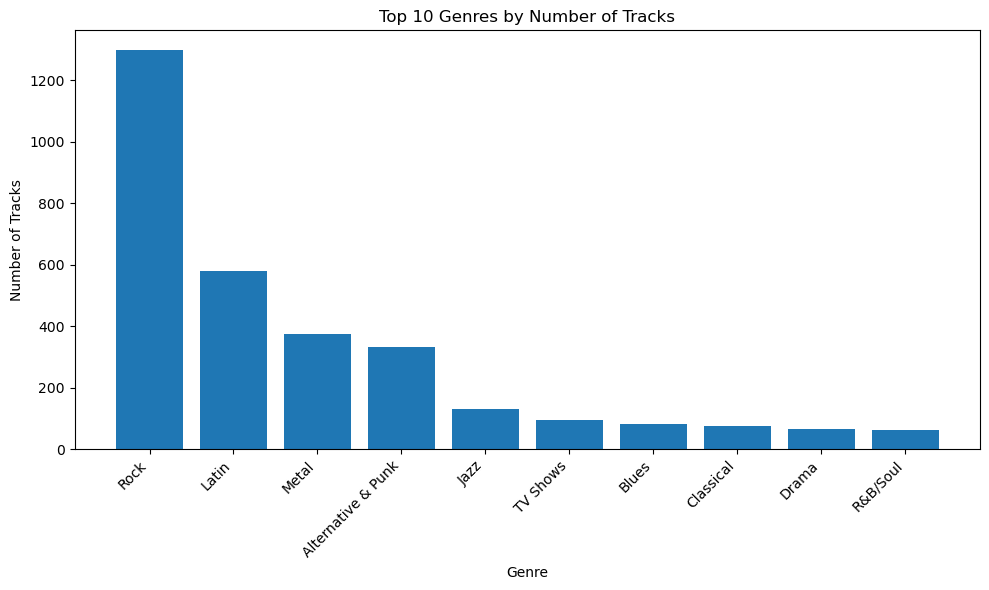

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(q1["genre"], q1["track_count"])

plt.xlabel("Genre")
plt.ylabel("Number of Tracks")
plt.title("Top 10 Genres by Number of Tracks")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Q2. Write a query to list the top 10 albums that contain the most tracks.

In [9]:
query = """
SELECT
    a.title AS album,
    ar.name AS artist,
    COUNT(t.track_id) AS track_count
FROM album AS a
JOIN artist AS ar
    ON a.artist_id = ar.artist_id
JOIN track AS t
    ON a.album_id = t.album_id
GROUP BY a.album_id, a.title, ar.name
ORDER BY track_count DESC
LIMIT 10;
"""

q2 = pd.read_sql_query(query, conn)

display(q2)

,album,artist,track_count
0,Greatest Hits,Lenny Kravitz,57
1,Minha Historia,Chico Buarque,34
2,Unplugged,Eric Clapton,30
3,"Lost, Season 3",Lost,26
4,"Lost, Season 1",Lost,25
5,"The Office, Season 3",The Office,25
6,My Way: The Best Of Frank Sinatra [Disc 1],Frank Sinatra,24
7,"Lost, Season 2",Lost,24
8,"Battlestar Galactica (Classic), Season 1",Battlestar Galactica (Classic),24
9,Afrociberdelia,Chico Science & Nação Zumbi,23


## Q3. Write a query to find the top 10 customers who spent the most money.

In [10]:
query = """
SELECT
    c.customer_id,
    c.first_name || ' ' || c.last_name AS customer,
    ROUND(SUM(i.total), 2) AS total_spent
FROM customer AS c
JOIN invoice AS i
    ON c.customer_id = i.customer_id
GROUP BY c.customer_id, c.first_name, c.last_name
ORDER BY total_spent DESC
LIMIT 10;
"""

q3 = pd.read_sql_query(query, conn)

display(q3)

,customer_id,customer,total_spent
0,5,František Wichterlová,144.54
1,6,Helena Holý,128.70
2,46,Hugh O'Reilly,114.84
3,58,Manoj Pareek,111.87
4,1,Luís Gonçalves,108.90
5,13,Fernanda Ramos,106.92
6,34,João Fernandes,102.96
7,3,François Tremblay,99.99
8,42,Wyatt Girard,99.99
9,17,Jack Smith,98.01


## Q4. Write a query to find the top 5 artists who generated the highest revenue from track sales.

In [11]:
query = """
SELECT
    ar.name AS artist,
    ROUND(SUM(il.unit_price * il.quantity), 2) AS revenue
FROM artist AS ar
JOIN album AS a
    ON ar.artist_id = a.artist_id
JOIN track AS t
    ON a.album_id = t.album_id
JOIN invoice_line AS il
    ON t.track_id = il.track_id
GROUP BY ar.artist_id, ar.name
ORDER BY revenue DESC
LIMIT 5;
"""

q4 = pd.read_sql_query(query, conn)

display(q4)

,artist,revenue
0,Queen,190.08
1,Jimi Hendrix,185.13
2,Nirvana,128.70
3,Red Hot Chili Peppers,128.70
4,Pearl Jam,127.71


## Q5. Countries by Average Revenue per Invoice

In [12]:
query = """
SELECT
    billing_country AS country,
    COUNT(invoice_id) AS invoice_count,
    ROUND(AVG(total), 2) AS avg_revenue_per_invoice
FROM invoice
GROUP BY billing_country
ORDER BY avg_revenue_per_invoice DESC;
"""

q5 = pd.read_sql_query(query, conn)

display(q5)

,country,invoice_count,avg_revenue_per_invoice
0,Czech Republic,30,9.11
1,Spain,11,8.91
2,Ireland,13,8.83
3,United Kingdom,28,8.77
4,India,21,8.72
5,Belgium,7,8.63
6,Germany,41,8.16
7,Australia,10,8.12
8,Norway,9,8.03
9,USA,131,7.94


## Q6. Write a query to find the media type with number of tracks.


In [13]:
query = """
SELECT
    mt.name AS media_type,
    COUNT(t.track_id) AS track_count
FROM media_type AS mt
LEFT JOIN track AS t
    ON mt.media_type_id = t.media_type_id
GROUP BY mt.media_type_id, mt.name
ORDER BY track_count DESC;
"""

q6 = pd.read_sql_query(query, conn)

display(q6)

,media_type,track_count
0,MPEG audio file,3034
1,Protected AAC audio file,237
2,Protected MPEG-4 video file,214
3,AAC audio file,11
4,Purchased AAC audio file,7


## Q7. Which artists have released tracks in more than one genre?

In [14]:
query = """
SELECT
    ar.name AS artist,
    COUNT(DISTINCT t.genre_id) AS genre_count,
    GROUP_CONCAT(DISTINCT g.name) AS genres
FROM artist AS ar
JOIN album AS a
    ON ar.artist_id = a.artist_id
JOIN track AS t
    ON a.album_id = t.album_id
JOIN genre AS g
    ON t.genre_id = g.genre_id
GROUP BY ar.artist_id, ar.name
HAVING COUNT(DISTINCT t.genre_id) > 1
ORDER BY genre_count DESC, artist;
"""

q7 = pd.read_sql_query(query, conn)

display(q7)

,artist,genre_count,genres
0,Iron Maiden,4,"Rock,Metal,Heavy Metal,Blues"
1,Audioslave,3,"Rock,Alternative & Punk,Alternative"
2,Battlestar Galactica,3,"Science Fiction,TV Shows,Sci Fi & Fantasy"
3,Gilberto Gil,3,"Soundtrack,Latin,Jazz"
4,Jamiroquai,3,"Rock,R&B/Soul,Electronica/Dance"
5,Lenny Kravitz,3,"Rock,Reggae,Metal"
6,Various Artists,3,"Pop,Soundtrack,Latin"
7,Amy Winehouse,2,"R&B/Soul,Pop"
8,Antônio Carlos Jobim,2,"Jazz,Latin"
9,Eric Clapton,2,"Blues,Latin"


## Q8. Write a query to list the top 10 longest tracks by duration.

In [15]:
query = """
SELECT
    t.track_id,
    t.name AS track,
    ar.name AS artist,
    t.milliseconds,
    ROUND(t.milliseconds / 60000.0, 2) AS duration_minutes
FROM track AS t
JOIN album AS a
    ON t.album_id = a.album_id
JOIN artist AS ar
    ON a.artist_id = ar.artist_id
ORDER BY t.milliseconds DESC
LIMIT 10;
"""

q8 = pd.read_sql_query(query, conn)

display(q8)

,track_id,track,artist,milliseconds,duration_minutes
0,2820,Occupation / Precipice,Battlestar Galactica,5286953,88.12
1,3224,Through a Looking Glass,Lost,5088838,84.81
2,3244,"Greetings from Earth, Pt. 1",Battlestar Galactica (Classic),2960293,49.34
3,3242,The Man With Nine Lives,Battlestar Galactica (Classic),2956998,49.28
4,3227,"Battlestar Galactica, Pt. 2",Battlestar Galactica (Classic),2956081,49.27
5,3226,"Battlestar Galactica, Pt. 1",Battlestar Galactica (Classic),2952702,49.21
6,3243,Murder On the Rising Star,Battlestar Galactica (Classic),2935894,48.93
7,3228,"Battlestar Galactica, Pt. 3",Battlestar Galactica (Classic),2927802,48.80
8,3248,Take the Celestra,Battlestar Galactica (Classic),2927677,48.79
9,3239,Fire In Space,Battlestar Galactica (Classic),2926593,48.78


## Q9. Top 5 Revenue Share percentage by Artist (Pie Chart)

In [16]:
query = """
WITH artist_revenue AS (
    SELECT
        ar.artist_id,
        ar.name AS artist,
        SUM(il.unit_price * il.quantity) AS revenue
    FROM artist AS ar
    JOIN album AS a
        ON ar.artist_id = a.artist_id
    JOIN track AS t
        ON a.album_id = t.album_id
    JOIN invoice_line AS il
        ON t.track_id = il.track_id
    GROUP BY ar.artist_id, ar.name
),
total_revenue AS (
    SELECT SUM(revenue) AS total_revenue
    FROM artist_revenue
)
SELECT
    artist,
    ROUND(revenue, 2) AS revenue,
    ROUND(
        revenue * 100.0 / total_revenue,
        2
    ) AS revenue_share_percentage
FROM artist_revenue, total_revenue
ORDER BY revenue DESC
LIMIT 5;
"""

q9 = pd.read_sql_query(query, conn)

display(q9)

,artist,revenue,revenue_share_percentage
0,Queen,190.08,4.04
1,Jimi Hendrix,185.13,3.93
2,Nirvana,128.70,2.73
3,Red Hot Chili Peppers,128.70,2.73
4,Pearl Jam,127.71,2.71


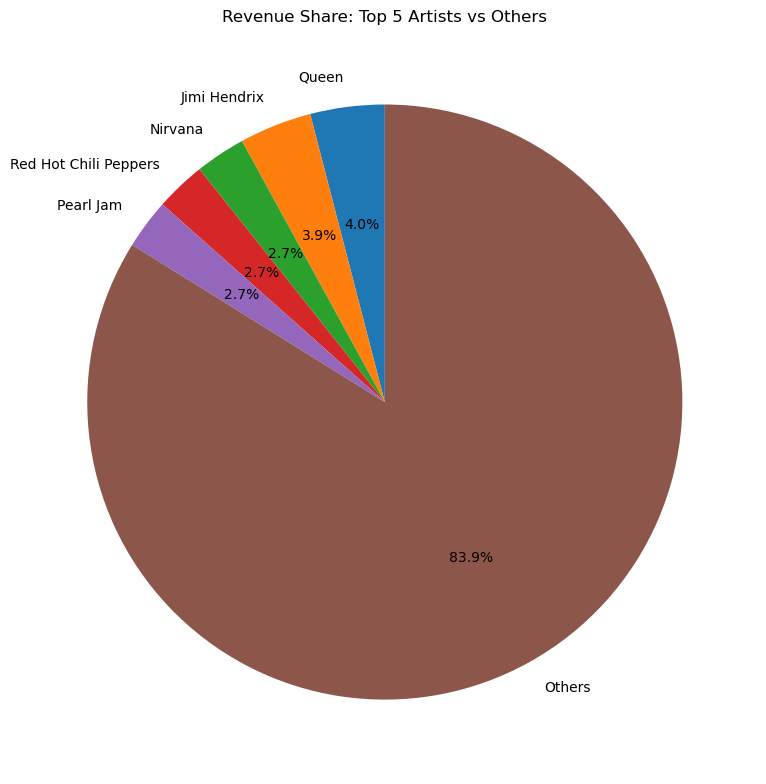

In [17]:
overall_revenue = pd.read_sql_query(
    """
    SELECT SUM(unit_price * quantity) AS total_revenue
    FROM invoice_line;
    """,
    conn
).iloc[0, 0]

q9_pie = q9[["artist", "revenue"]].copy()

others_revenue = overall_revenue - q9_pie["revenue"].sum()

if others_revenue > 0:
    q9_pie.loc[len(q9_pie)] = ["Others", others_revenue]

plt.figure(figsize=(8, 8))

plt.pie(
    q9_pie["revenue"],
    labels=q9_pie["artist"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share: Top 5 Artists vs Others")

plt.tight_layout()
plt.show()

## Q10. Revenue by Genre (Rock, Latin, Metal) in Each Country (Stacked Column Chart)

In [18]:
query = """
SELECT
    i.billing_country AS country,
    g.name AS genre,
    ROUND(SUM(il.unit_price * il.quantity), 2) AS revenue
FROM invoice AS i
JOIN invoice_line AS il
    ON i.invoice_id = il.invoice_id
JOIN track AS t
    ON il.track_id = t.track_id
JOIN genre AS g
    ON t.genre_id = g.genre_id
WHERE g.name IN ('Rock', 'Latin', 'Metal')
GROUP BY i.billing_country, g.name
ORDER BY i.billing_country, revenue DESC;
"""

q10 = pd.read_sql_query(query, conn)

display(q10)

,country,genre,revenue
0,Argentina,Rock,10.89
1,Argentina,Metal,1.98
2,Argentina,Latin,1.98
3,Australia,Rock,33.66
4,Australia,Metal,13.86
...,...,...,...
65,USA,Metal,122.76
66,USA,Latin,21.78
67,United Kingdom,Rock,164.34
68,United Kingdom,Metal,30.69


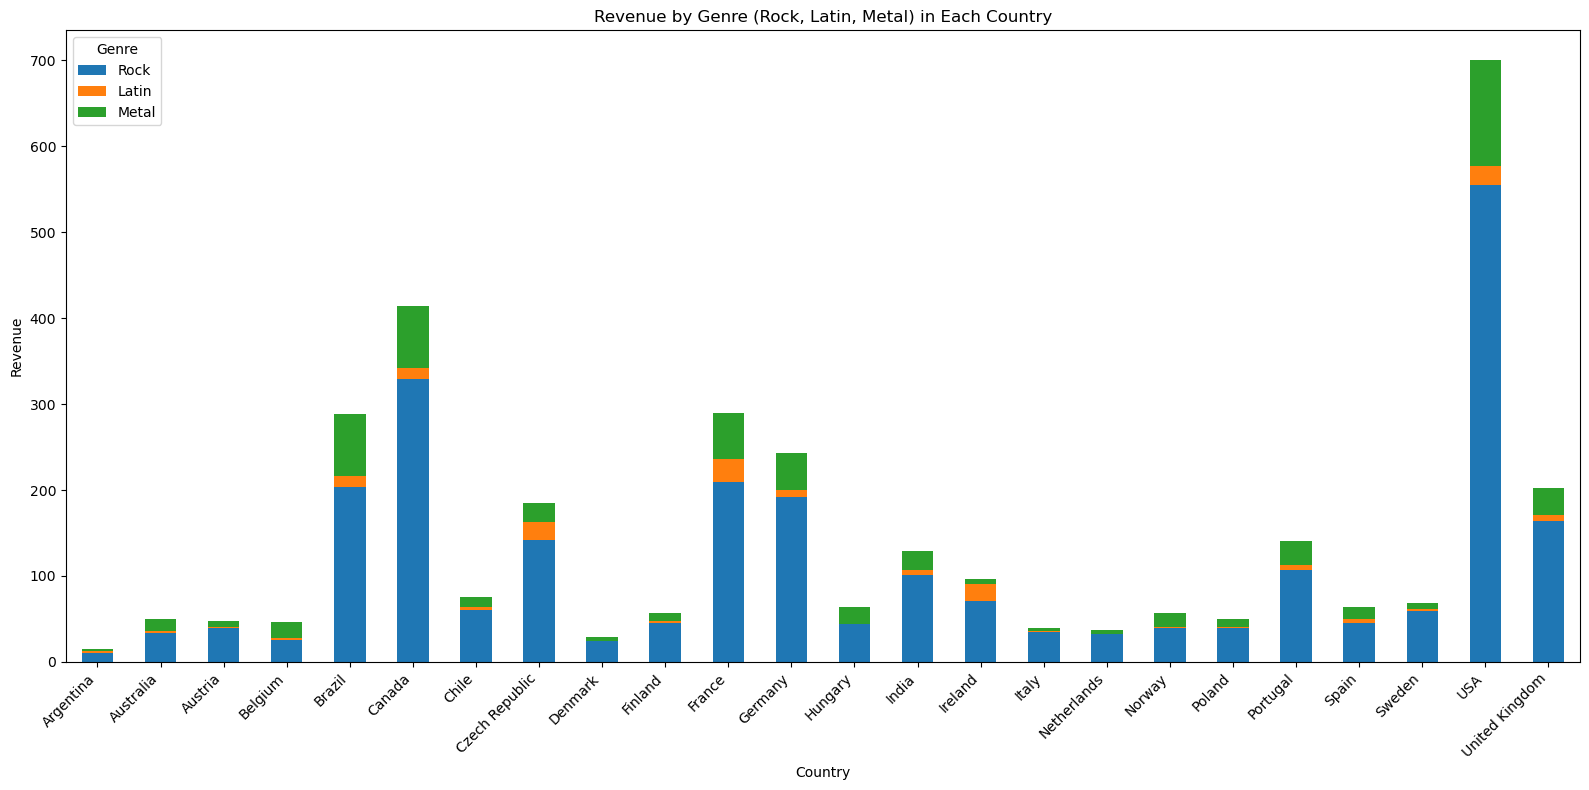

In [19]:
q10_pivot = q10.pivot(
    index="country",
    columns="genre",
    values="revenue"
).fillna(0)

genre_order = [
    g for g in ["Rock", "Latin", "Metal"]
    if g in q10_pivot.columns
]

q10_pivot = q10_pivot[genre_order]

ax = q10_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 8)
)

ax.set_xlabel("Country")
ax.set_ylabel("Revenue")
ax.set_title(
    "Revenue by Genre (Rock, Latin, Metal) in Each Country"
)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Genre")
plt.tight_layout()
plt.show()